# Livrable 3 — Captioning d'Image (COCO 2017)
## Projet DS Leyenda — TouNum

---

Ce livrable met en oeuvre un pipeline complet de **generation automatique de descriptions**
(image captioning) sur le dataset COCO 2017.

```
Images COCO 2017  -->  Encodeur CNN (InceptionV3)  -->  Representation visuelle
                                                               |
                        Tokenisation des captions              |
                                |                              v
                       Pipeline tf.data  <----------  CNN + RNN / Transformer
                                                               |
                        Interface interactive  <--  Evaluation & comparaison
```

| Partie | Contenu |
|--------|---------|
| **1. Donnees** | Chargement COCO 2017, exploration, statistiques |
| **2. Pretraitement images** | InceptionV3, extraction features, cache disque |
| **3. Pretraitement texte** | Tokenisation, vocabulaire, padding |
| **4. Split & Pipeline** | Train/Val/Test 80/10/10, tf.data |
| **5. Modele CNN + RNN** | CNN Encoder, Attention Bahdanau, GRU Decoder |
| **6. Modele CNN + Transformer** | Decoder Transformer, cross-attention |
| **7. Comparaison** | BLEU, courbes, exemples qualitatifs |
| **8. Interface Interactive** | Upload image -> caption (RNN ou Transformer) |

---
## 0. Imports & Configuration

In [18]:
# Installations supplémentaires

%pip install tqdm nltk


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import collections
import random
import json
import os
import time
import pickle
from PIL import Image
from tqdm import tqdm

print(f'TensorFlow {tf.__version__}')
print(f'GPU disponible : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.14.0
GPU disponible : True


In [20]:
# ============================================================
# CONFIGURATION GLOBALE
# ============================================================
ANNOTATION_FILE = 'notebooks/data_3/annotations/captions_train2017.json'
IMAGE_PATH      = 'notebooks/data_3/train2017/'
NUM_IMAGES      = 30000     # None = toutes les images disponibles (COCO train2017 : 118 287)
TOP_K           = 5000

# --- Architecture Transformer ---
EMBEDDING_DIM = 256
UNITS         = 512
NUM_HEADS     = 4
FF_DIM        = 1024     # augmente la capacite du FFN
NUM_LAYERS_TR = 3        # un bloc de plus
DROPOUT_TR    = 0.3      # dropout plus agressif (regularisation)

# --- Entrainement ---
BATCH_SIZE       = 64
BUFFER_SIZE      = 1000
EPOCHS_RNN       = 15
EPOCHS_TR        = 20    # plus d epochs avec le warmup
WARMUP_STEPS     = 4000  # palier de montee du LR
LABEL_SMOOTHING  = 0.1   # lisse les cibles -> moins d overconfidence
GRAD_CLIP        = 1.0   # clipping du gradient

# --- Inference ---
BEAM_SIZE = 5            # beam search : candidats simultanes

# --- Sauvegardes ---
CHECKPOINT_DIR_RNN = 'notebooks/checkpoints_rnn/'
CHECKPOINT_DIR_TR  = 'notebooks/checkpoints_transformer/'
TOKENIZER_PATH     = 'notebooks/tokenizer_coco.pkl'

SEED = 42
import random, numpy as np, tensorflow as tf
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('Configuration chargee.')

Configuration chargee.


---
## 1. Chargement et Exploration des Donnees

### Dataset COCO 2017

**COCO** (Common Objects in Context) est le benchmark standard du captioning.

| Statistique | Valeur |
|-------------|--------|
| Images train2017 | 118 287 |
| Captions par image | ~5 (annotations humaines) |
| Total captions | ~591 000 |
| Format | JSON (annotations) + JPEG (images) |

Chaque annotation JSON a la forme :
```json
{"image_id": 391895, "caption": "A man riding a horse in a field."}
```

### Tokens speciaux

| Token | Role |
|-------|------|
| `<start>` | Debut de chaque caption (entree decodeur) |
| `<end>` | Fin (condition d'arret de la generation) |
| `<unk>` | Mots hors-vocabulaire |
| `<pad>` | Padding pour egaliser les longueurs |

In [21]:
with open(ANNOTATION_FILE, 'r') as f:
    annotations = json.load(f)

print(f'Nombre d annotations : {len(annotations["annotations"])}')
print(f'Exemple : {annotations["annotations"][0]}')

# Grouper les captions par chemin d image
image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    caption    = '<start> ' + val['caption'] + ' <end>'
    image_path = IMAGE_PATH + '%012d.jpg' % val['image_id']
    image_path_to_caption[image_path].append(caption)

# Selectionner NUM_IMAGES images aleatoirement
all_image_paths = list(image_path_to_caption.keys())
random.shuffle(all_image_paths)
selected_paths  = all_image_paths if NUM_IMAGES is None else all_image_paths[:NUM_IMAGES]

# Construire les listes (image_path, caption)
all_captions, all_img_paths = [], []
for image_path in selected_paths:
    captions = image_path_to_caption[image_path]
    all_captions.extend(captions)
    all_img_paths.extend([image_path] * len(captions))

print(f'Images selectionnees    : {len(selected_paths):,}')
print(f'Paires (image, caption) : {len(all_captions):,}')
print(f'Captions / image (moy.) : {len(all_captions)/len(selected_paths):.1f}')

Nombre d annotations : 591753
Exemple : {'image_id': 203564, 'id': 37, 'caption': 'A bicycle replica with a clock as the front wheel.'}
Images selectionnees    : 30,000
Paires (image, caption) : 150,091
Captions / image (moy.) : 5.0


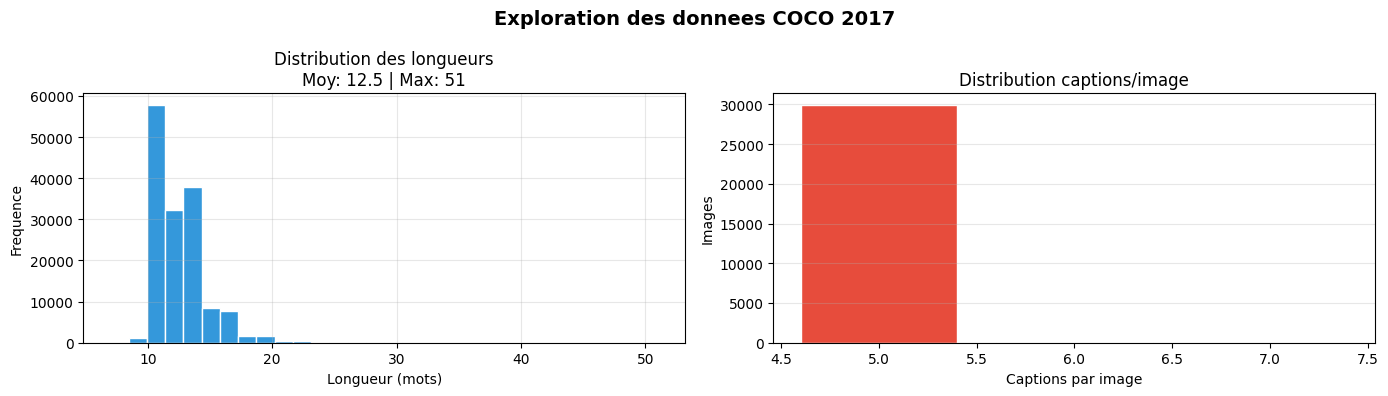

=== Exemples ===

Image : 000000519945.jpg
  <start> a small boats in a body of water  <end>
  <start> a large starcraft boat, on a lake, with a flag that reads "ski life" on it. <end>

Image : 000000305075.jpg
  <start> A white spa-like bathroom with towels and flowers. <end>
  <start> A series of four pictures of a bathroom. <end>

Image : 000000191561.jpg
  <start> People splitting up a box of mixed doughnuts. <end>
  <start> He has his pinky finger on the donut that he wants. <end>


In [22]:
caption_lengths = [len(c.split()) for c in all_captions]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Exploration des donnees COCO 2017', fontsize=14, fontweight='bold')

axes[0].hist(caption_lengths, bins=30, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Longueur (mots)'); axes[0].set_ylabel('Frequence')
axes[0].set_title(
    f'Distribution des longueurs\n'
    f'Moy: {np.mean(caption_lengths):.1f} | Max: {max(caption_lengths)}'
)
axes[0].grid(alpha=0.3)

from collections import Counter
caps_per_image = [len(image_path_to_caption[p]) for p in selected_paths]
cnt = Counter(caps_per_image)
axes[1].bar(cnt.keys(), cnt.values(), color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('Captions par image'); axes[1].set_ylabel('Images')
axes[1].set_title('Distribution captions/image')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('=== Exemples ===')
for i in range(3):
    img_p = selected_paths[i]
    print(f'\nImage : {os.path.basename(img_p)}')
    for cap in image_path_to_caption[img_p][:2]:
        print(f'  {cap}')

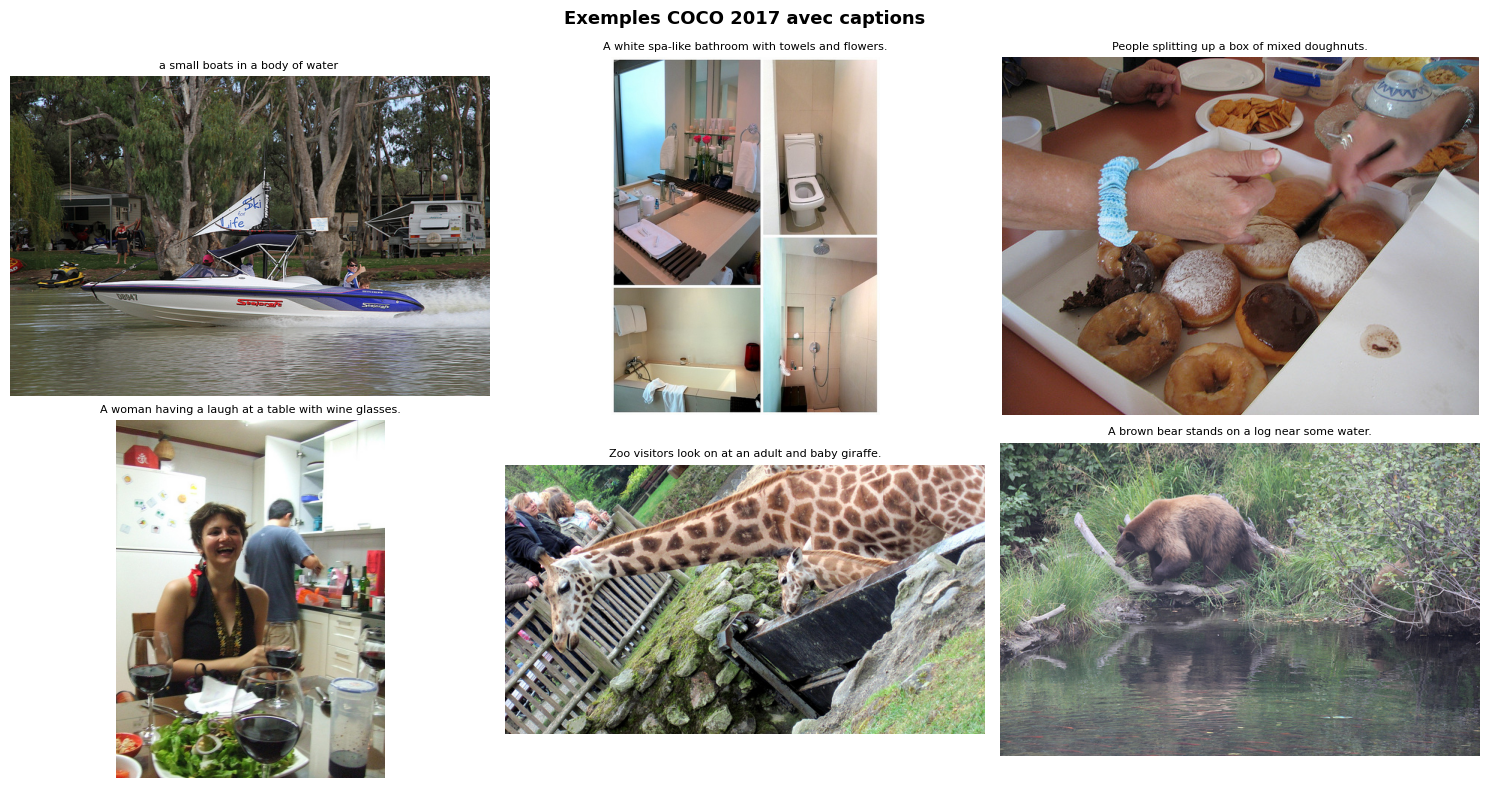

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Exemples COCO 2017 avec captions', fontsize=13, fontweight='bold')
for idx, ax in enumerate(axes.flat):
    img_path = selected_paths[idx]
    try:
        img = Image.open(img_path).convert('RGB')
        cap_clean = image_path_to_caption[img_path][0]
        cap_clean = cap_clean.replace('<start> ','').replace(' <end>','')
        ax.imshow(img)
        ax.set_title(cap_clean[:60], fontsize=8)
    except Exception as e:
        ax.set_title(f'Erreur: {e}', fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

---
## 2. Pretraitement des Images — InceptionV3

### Strategie : extraction de features prealable

Plutot que de passer chaque image dans InceptionV3 a chaque epoch, on **precalcule**
les features une seule fois et on les sauvegarde sur disque (`.npy`).

```
Image JPEG  ->  InceptionV3 (gele)  ->  (8, 8, 2048)  ->  reshape  ->  (64, 2048)
                                                                           |
                                                               Sauvegarde .npy
```

**Avantage** : l'entrainement lit des tableaux numpy -> 10x plus rapide.

### Pourquoi garder la dimension spatiale (64 = 8x8) ?

En gardant les 64 positions spatiales (au lieu de GlobalAvgPool), l'attention
peut apprendre **quelle region** de l'image regarder pour predire chaque mot.
C'est la cle du mecanisme d'attention de Bahdanau.

In [24]:
# ---- Modele d'extraction InceptionV3 ----
inception = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet')
image_features_extract_model = tf.keras.Model(
    inception.input, inception.layers[-1].output
)  # sortie : (batch, 8, 8, 2048)

def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299, 299))
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

# ---- Extraction et sauvegarde ----
encode_train = sorted(set(all_img_paths))
to_encode    = [p for p in encode_train if not os.path.exists(p + '.npy')]
print(f'Images a encoder : {len(to_encode)} / {len(encode_train)}')

if to_encode:
    image_dataset = tf.data.Dataset.from_tensor_slices(to_encode)
    image_dataset = image_dataset.map(
        load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(16)
    for img_batch, path_batch in tqdm(image_dataset, desc='InceptionV3'):
        batch_features = image_features_extract_model(img_batch)
        # (16, 8, 8, 2048) -> (16, 64, 2048)
        batch_features = tf.reshape(batch_features,
                                    (batch_features.shape[0], -1, batch_features.shape[3]))
        for feat, path in zip(batch_features, path_batch):
            np.save(path.numpy().decode('utf-8'), feat.numpy())
    print('Extraction terminee.')
else:
    print('Toutes les features sont deja en cache.')

sample_feat = np.load(encode_train[0] + '.npy')
print(f'Shape feature : {sample_feat.shape}  (64 positions x 2048 features)')

Images a encoder : 0 / 30000
Toutes les features sont deja en cache.
Shape feature : (64, 2048)  (64 positions x 2048 features)


---
## 3. Pretraitement du Texte — Tokenisation

```
Caption brute  ->  Tokenizer (top 5 000 mots)  ->  Sequence d entiers  ->  Padding
'<start> A cat sits... <end>'  ->  [1, 4, 312, 87, 2]  ->  [1, 4, 312, 87, 2, 0, 0, ...]
```

| Parametre | Valeur |
|-----------|--------|
| Vocabulaire | 5 000 mots + unk + pad |
| Filtres | Ponctuation supprimee |
| Padding | Post (zeros a droite) |
| Max length | Calculee depuis le corpus |

In [25]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=TOP_K,
    oov_token='<unk>',
    filters='!"#$%&()*+.,-/:;=?@[\\]^_`{|}~ '
)
tokenizer.fit_on_texts(all_captions)
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0]       = '<pad>'

train_seqs  = tokenizer.texts_to_sequences(all_captions)
cap_vector  = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post')
max_length  = max(len(s) for s in train_seqs)
vocab_size  = TOP_K + 1

print(f'Vocabulaire    : {vocab_size} mots')
print(f'Longueur max   : {max_length} tokens')
print(f'Shape cap_vector: {cap_vector.shape}')
print(f'Index <start>  : {tokenizer.word_index.get("<start>", -1)}')
print(f'Index <end>    : {tokenizer.word_index.get("<end>", -1)}')

# Sauvegarde
with open(TOKENIZER_PATH, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f'Tokenizer sauvegarde : {TOKENIZER_PATH}')

Vocabulaire    : 5001 mots
Longueur max   : 51 tokens
Shape cap_vector: (150091, 51)
Index <start>  : 3
Index <end>    : 4
Tokenizer sauvegarde : notebooks/tokenizer_coco.pkl


---
## 4. Split Train / Val / Test et Pipeline tf.data

### Split au niveau des images (80 / 10 / 10)

On sépare les **images** (pas les paires) pour éviter le data leakage.
Toutes les captions d'une même image restent dans le même split.

```
6 000 images  ->  Train : 80% (4 800 images, ~24 000 paires)
              ->  Val   : 10% (  600 images, ~ 3 000 paires)
              ->  Test  : 10% (  600 images, ~ 3 000 paires)
```

### Pipeline lazy

Les features `.npy` sont chargees en lazy a partir du disque,
ce qui evite de tout charger en RAM.

In [26]:
img_to_cap_vector = collections.defaultdict(list)
for img_path, cap_vec in zip(all_img_paths, cap_vector):
    img_to_cap_vector[img_path].append(cap_vec)

img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)

train_end = int(len(img_keys) * 0.80)
val_end   = int(len(img_keys) * 0.90)

keys_train = img_keys[:train_end]
keys_val   = img_keys[train_end:val_end]
keys_test  = img_keys[val_end:]

def build_split(keys):
    img_list, cap_list = [], []
    for k in keys:
        caps = img_to_cap_vector[k]
        img_list.extend([k] * len(caps))
        cap_list.extend(caps)
    return img_list, cap_list

img_name_train, cap_train = build_split(keys_train)
img_name_val,   cap_val   = build_split(keys_val)
img_name_test,  cap_test  = build_split(keys_test)

print(f'Train : {len(img_name_train):>6} paires  ({len(keys_train)} images)')
print(f'Val   : {len(img_name_val):>6} paires  ({len(keys_val)} images)')
print(f'Test  : {len(img_name_test):>6} paires  ({len(keys_test)} images)')

Train : 120069 paires  (24000 images)
Val   :  15010 paires  (3000 images)
Test  :  15012 paires  (3000 images)


In [27]:
def map_func(img_name, cap):
    img_tensor = np.load(img_name.decode('utf-8') + '.npy')
    return img_tensor, cap

def make_dataset(img_list, cap_list, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((img_list, cap_list))
    ds = ds.map(
        lambda i, c: tf.numpy_function(map_func, [i, c], [tf.float32, tf.int32]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle:
        ds = ds.shuffle(BUFFER_SIZE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(img_name_train, cap_train, shuffle=True)
val_dataset   = make_dataset(img_name_val,   cap_val,   shuffle=False)
test_dataset  = make_dataset(img_name_test,  cap_test,  shuffle=False)
num_steps_train = len(img_name_train) // BATCH_SIZE

for feat_batch, cap_batch in train_dataset.take(1):
    print(f'Features : {feat_batch.shape}  (batch, 64 positions, 2048 features)')
    print(f'Captions : {cap_batch.shape}')

Features : (64, 64, 2048)  (batch, 64 positions, 2048 features)
Captions : (64, 51)


---
## 5. Modele CNN Encoder + RNN Decoder (Attention Bahdanau)

### Architecture

```
Features InceptionV3 (batch, 64, 2048)
         |
     CNN Encoder (Dense 2048->256)
         |
     (batch, 64, 256)  <- 64 positions spatiales
         |
     Attention Bahdanau  <-- etat GRU h_{t-1}
         |
     Vecteur de contexte (batch, 256)
         |
     Concat [contexte, embedding(mot_courant)]
         |
     GRU Cell (512 unites)
         |
     Dense(vocab_size) -> logits
```

### Mecanisme d'Attention Bahdanau

Pour predire le t-ieme mot :
1. Score = tanh(W1 x features + W2 x h_{t-1})
2. Poids = softmax(V x score) : distribution sur 64 positions
3. Contexte = somme(poids x features)

Le reseau apprend a **regarder** les bonnes regions selon le mot a predire.

In [28]:
class CNN_Encoder(tf.keras.Model):
    # Projette les features InceptionV3 (64, 2048) -> (64, embedding_dim)
    def __init__(self, embedding_dim):
        super().__init__()
        self.fc = layers.Dense(embedding_dim)

    def call(self, x):
        return tf.nn.relu(self.fc(x))

enc_test = CNN_Encoder(EMBEDDING_DIM)
print(f'CNN Encoder : (batch, 64, 2048) -> {enc_test(tf.zeros((2,64,2048))).shape}')

CNN Encoder : (batch, 64, 2048) -> (2, 64, 256)


In [29]:
class BahdanauAttention(tf.keras.Model):
    # Attention additive : combine features image et etat GRU
    # features : (batch, 64, embedding_dim)
    # hidden   : (batch, units)
    # -> context_vector (batch, embedding_dim) + attention_weights (batch, 64, 1)
    def __init__(self, units):
        super().__init__()
        self.W1 = layers.Dense(units)  # projette les features
        self.W2 = layers.Dense(units)  # projette l etat cache
        self.V  = layers.Dense(1)      # score scalaire par position

    def call(self, features, hidden):
        hidden_exp       = tf.expand_dims(hidden, 1)           # (batch, 1, units)
        score            = self.V(tf.nn.tanh(
            self.W1(features) + self.W2(hidden_exp)))          # (batch, 64, 1)
        attention_weights = tf.nn.softmax(score, axis=1)       # (batch, 64, 1)
        context_vector   = tf.reduce_sum(
            attention_weights * features, axis=1)              # (batch, embed_dim)
        return context_vector, attention_weights

att_test = BahdanauAttention(UNITS)
ctx, attn_w = att_test(tf.zeros((2,64,EMBEDDING_DIM)), tf.zeros((2,UNITS)))
print(f'Contexte : {ctx.shape}  |  Poids attention : {attn_w.shape}')

Contexte : (2, 256)  |  Poids attention : (2, 64, 1)


In [30]:
class RNN_Decoder(tf.keras.Model):
    # Decodeur GRU avec attention de Bahdanau
    # Genere la description mot par mot
    def __init__(self, embedding_dim, units, vocab_size):
        super().__init__()
        self.units     = units
        self.embedding = layers.Embedding(vocab_size, embedding_dim)
        self.gru = layers.GRU(units,
                              return_sequences=True,
                              return_state=True,
                              recurrent_initializer='glorot_uniform')
        self.fc1       = layers.Dense(units)
        self.fc2       = layers.Dense(vocab_size)
        self.attention = BahdanauAttention(units)

    def call(self, x, features, hidden):
        context_vector, attention_weights = self.attention(features, hidden)
        x = self.embedding(x)                                       # (batch, 1, embed)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)  # (batch, 1, 2*embed)
        output, state = self.gru(x)
        y = self.fc1(tf.reshape(output, (-1, output.shape[2])))
        y = self.fc2(y)                                             # (batch, vocab_size)
        return y, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

encoder_rnn = CNN_Encoder(EMBEDDING_DIM)
decoder_rnn = RNN_Decoder(EMBEDDING_DIM, UNITS, vocab_size)
print('Modele RNN instancie.')

Modele RNN instancie.


In [31]:
loss_object_rnn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_fn_rnn(real, pred):
    mask = tf.cast(tf.math.logical_not(tf.math.equal(real, 0)), tf.float32)
    return tf.reduce_mean(loss_object_rnn(real, pred) * mask)

optimizer_rnn = tf.keras.optimizers.Adam()
ckpt_rnn      = tf.train.Checkpoint(encoder=encoder_rnn, decoder=decoder_rnn,
                                     optimizer=optimizer_rnn)
ckpt_mgr_rnn  = tf.train.CheckpointManager(ckpt_rnn, CHECKPOINT_DIR_RNN, max_to_keep=3)

start_epoch_rnn = 0
if ckpt_mgr_rnn.latest_checkpoint:
    start_epoch_rnn = int(ckpt_mgr_rnn.latest_checkpoint.split('-')[-1])
    ckpt_rnn.restore(ckpt_mgr_rnn.latest_checkpoint)
    print(f'Checkpoint RNN restaure : epoch {start_epoch_rnn}')
else:
    print('Entrainement RNN from scratch.')

Entrainement RNN from scratch.


In [32]:
@tf.function
def train_step_rnn(img_tensor, target):
    loss   = 0
    hidden = decoder_rnn.reset_state(batch_size=target.shape[0])
    dec_in = tf.expand_dims(
        [tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:
        features = encoder_rnn(img_tensor)
        for i in range(1, target.shape[1]):
            preds, hidden, _ = decoder_rnn(dec_in, features, hidden)
            loss += loss_fn_rnn(target[:, i], preds)
            dec_in = tf.expand_dims(target[:, i], 1)   # Teacher forcing

    total_loss = loss / int(target.shape[1])
    variables  = encoder_rnn.trainable_variables + decoder_rnn.trainable_variables
    grads      = tape.gradient(loss, variables)
    optimizer_rnn.apply_gradients(zip(grads, variables))
    return loss, total_loss

@tf.function
def val_step_rnn(img_tensor, target):
    loss   = 0
    hidden = decoder_rnn.reset_state(batch_size=target.shape[0])
    dec_in = tf.expand_dims(
        [tokenizer.word_index['<start>']] * target.shape[0], 1)
    features = encoder_rnn(img_tensor)
    for i in range(1, target.shape[1]):
        preds, hidden, _ = decoder_rnn(dec_in, features, hidden)
        loss += loss_fn_rnn(target[:, i], preds)
        dec_in = tf.expand_dims(target[:, i], 1)
    return loss / int(target.shape[1])

print('Fonctions train_step et val_step RNN compilees.')

Fonctions train_step et val_step RNN compilees.


Entrainement CNN+RNN | Epochs: 15 | Batch: 64
-------------------------------------------------------
  Ep  1 | B    0 | loss 1.9366
  Ep  1 | B  100 | loss 1.0730
  Ep  1 | B  200 | loss 0.9026
  Ep  1 | B  300 | loss 0.8151
  Ep  1 | B  400 | loss 0.8345
  Ep  1 | B  500 | loss 0.8050
  Ep  1 | B  600 | loss 0.7298
  Ep  1 | B  700 | loss 0.7526
  Ep  1 | B  800 | loss 0.7334
  Ep  1 | B  900 | loss 0.6930
  Ep  1 | B 1000 | loss 0.7555
  Ep  1 | B 1100 | loss 0.6946
  Ep  1 | B 1200 | loss 0.7925
  Ep  1 | B 1300 | loss 0.6516
  Ep  1 | B 1400 | loss 0.7240
  Ep  1 | B 1500 | loss 0.7081
  Ep  1 | B 1600 | loss 0.6490
  Ep  1 | B 1700 | loss 0.6870
  Ep  1 | B 1800 | loss 0.6365
Epoch  1/15 | Train: 0.7676 | Val: 0.6931 | 897s
  Ep  2 | B    0 | loss 0.6526
  Ep  2 | B  100 | loss 0.6342
  Ep  2 | B  200 | loss 0.6414
  Ep  2 | B  300 | loss 0.7124
  Ep  2 | B  400 | loss 0.6273
  Ep  2 | B  500 | loss 0.6878
  Ep  2 | B  600 | loss 0.6342
  Ep  2 | B  700 | loss 0.6231
  Ep  2 | B 

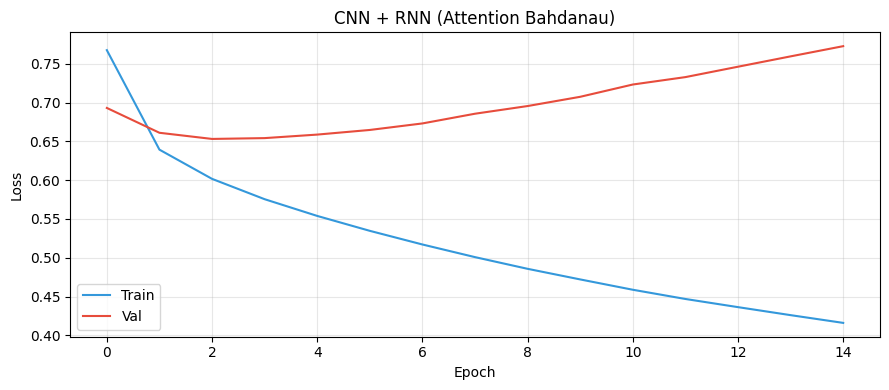

In [33]:
train_losses_rnn, val_losses_rnn = [], []

print(f'Entrainement CNN+RNN | Epochs: {EPOCHS_RNN} | Batch: {BATCH_SIZE}')
print('-' * 55)

for epoch in range(start_epoch_rnn, EPOCHS_RNN):
    t0 = time.time()
    total_train = total_val = 0

    for batch, (img_t, cap_t) in enumerate(train_dataset):
        _, t_loss = train_step_rnn(img_t, cap_t)
        total_train += t_loss
        if batch % 100 == 0:
            print(f'  Ep {epoch+1:2d} | B {batch:4d} | loss {t_loss:.4f}')

    for img_v, cap_v in val_dataset:
        total_val += val_step_rnn(img_v, cap_v)

    n_val_steps = len(img_name_val) // BATCH_SIZE + 1
    avg_tr = float(total_train / num_steps_train)
    avg_vl = float(total_val   / n_val_steps)
    train_losses_rnn.append(avg_tr)
    val_losses_rnn.append(avg_vl)

    if (epoch + 1) % 5 == 0:
        ckpt_mgr_rnn.save()
    print(f'Epoch {epoch+1:2d}/{EPOCHS_RNN} | '
          f'Train: {avg_tr:.4f} | Val: {avg_vl:.4f} | {time.time()-t0:.0f}s')

ckpt_mgr_rnn.save()
plt.figure(figsize=(9,4))
plt.plot(train_losses_rnn, label='Train', color='#3498db')
plt.plot(val_losses_rnn,   label='Val',   color='#e74c3c')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('CNN + RNN (Attention Bahdanau)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

=== Evaluation qualitative — CNN + RNN ===

Reel  : <start> a zebra standing next to a lot of trees <end>
Predit: a couple of zebras standing in a zoo



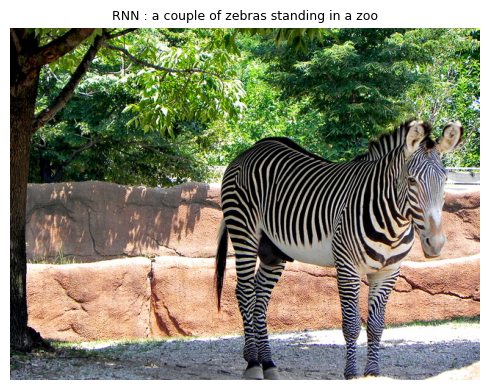

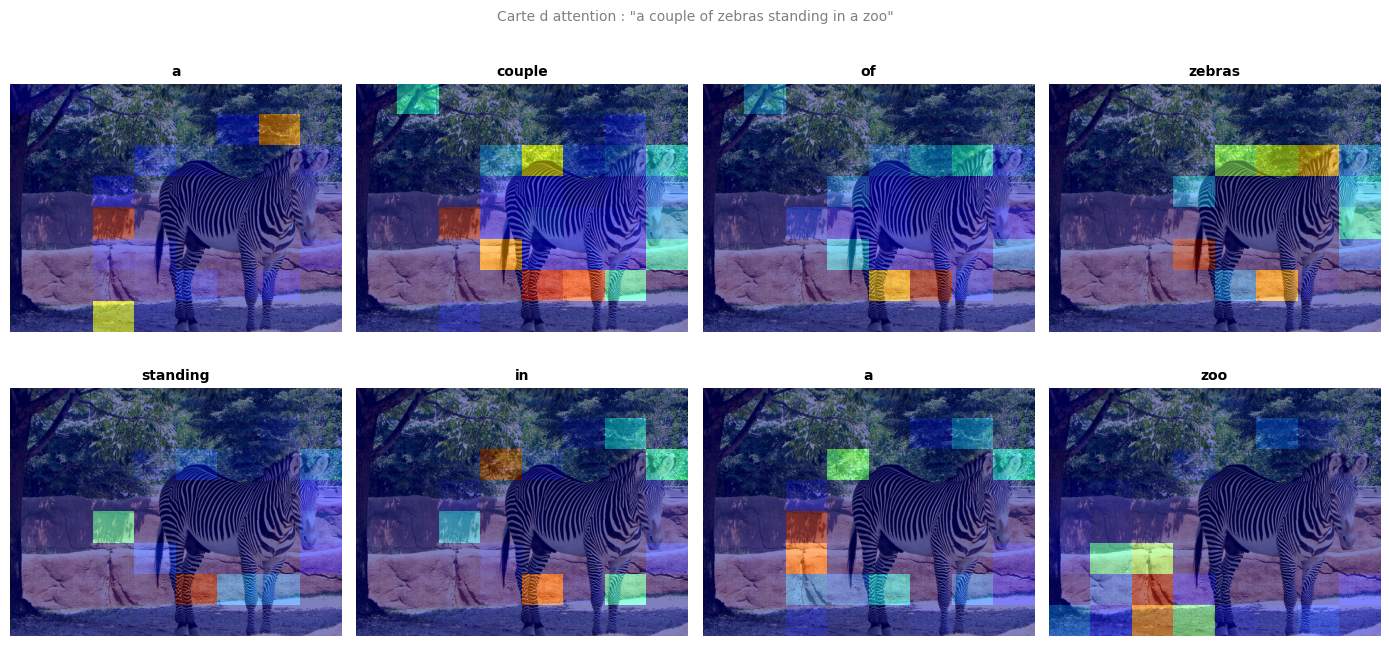

Reel  : <start> a group of green vegetables with some radishes and cauliflower <end>
Predit: a bowl filled with vegetables and rice



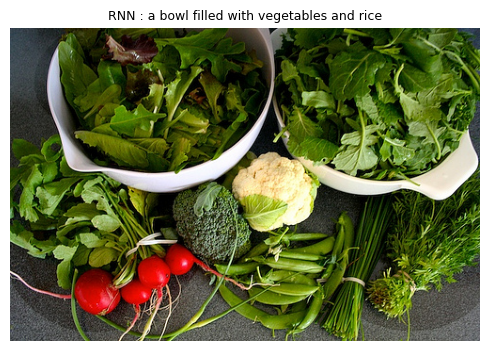

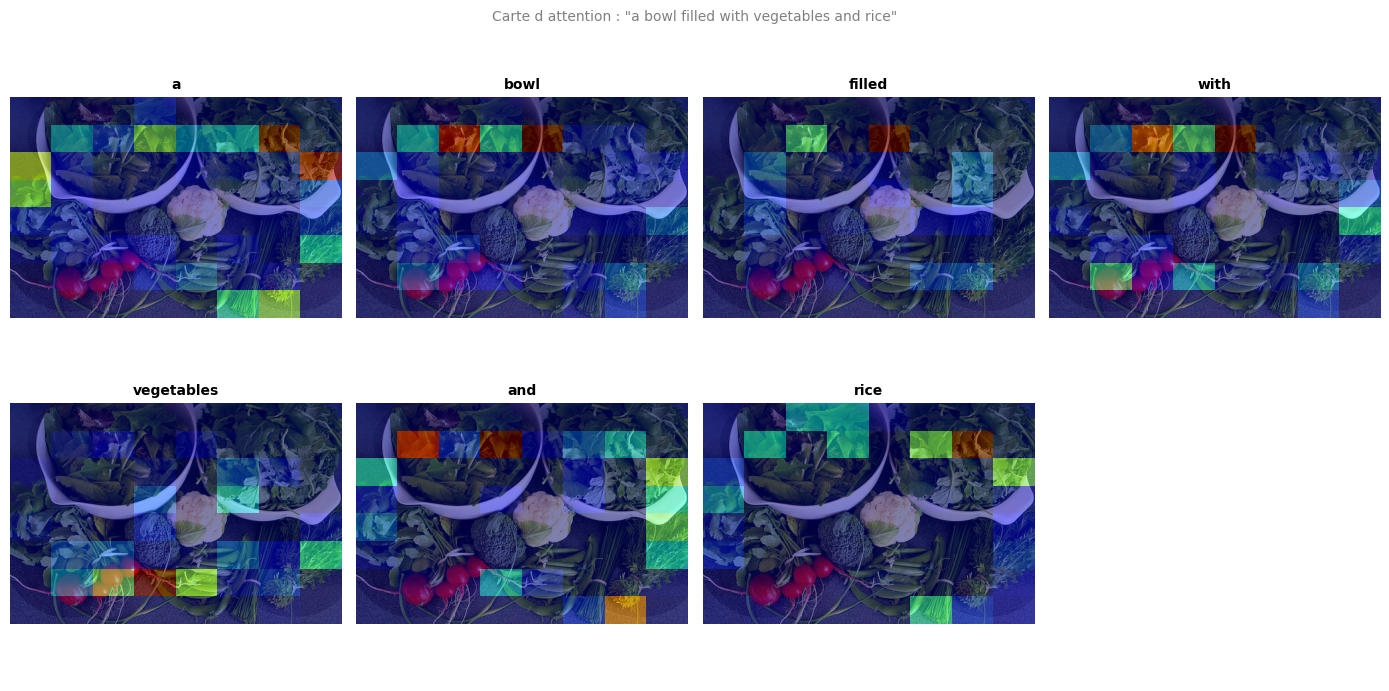

Reel  : <start> a japanese meal with a friend at a restaurant <end>
Predit: a table topped with a variety of food



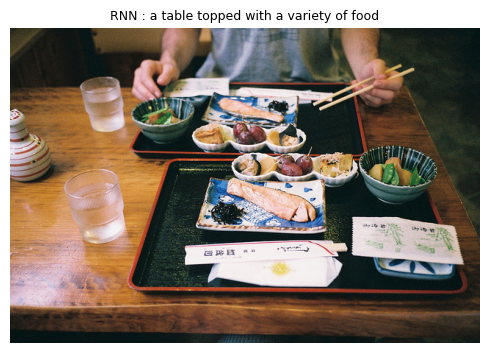

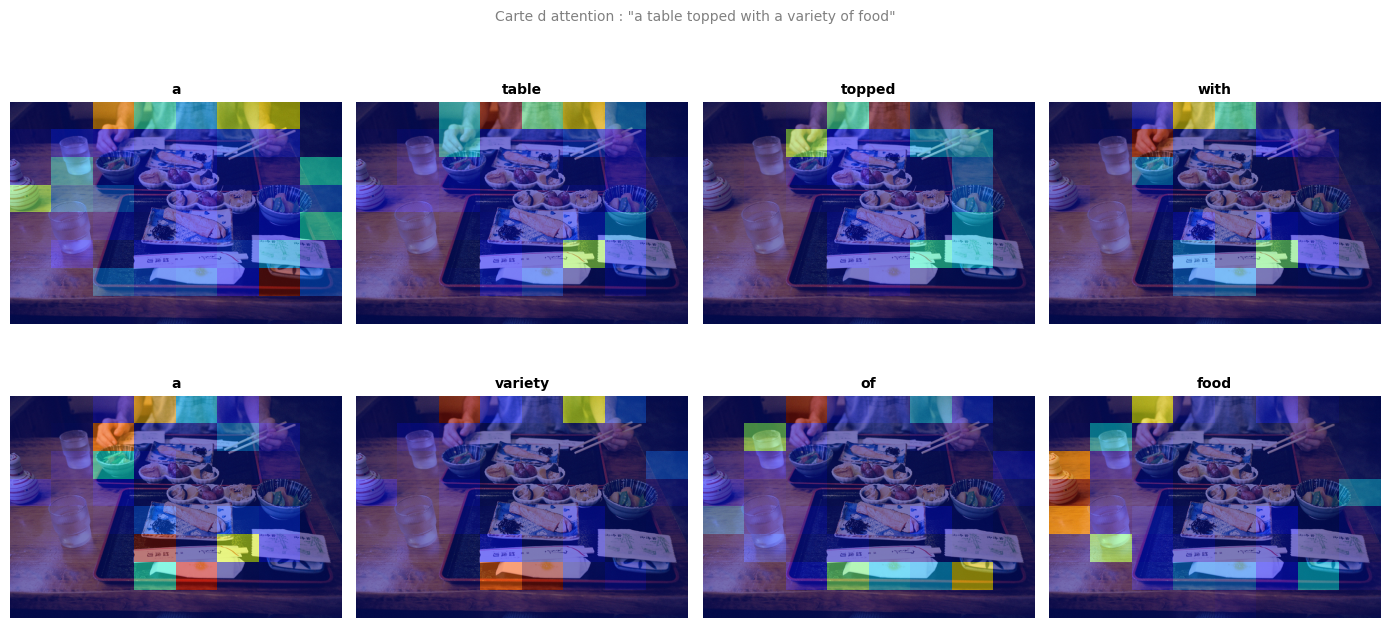

In [34]:
def evaluate_rnn(image_path):
    # Genere un caption + les poids d attention pour chaque mot
    attention_plot = np.zeros((max_length, 64))
    hidden  = decoder_rnn.reset_state(batch_size=1)
    img, _  = load_image(image_path)
    feat    = image_features_extract_model(tf.expand_dims(img, 0))
    feat    = tf.reshape(feat, (feat.shape[0], -1, feat.shape[3]))
    feat    = encoder_rnn(feat)
    dec_in  = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result  = []
    for i in range(max_length):
        preds, hidden, attn_w = decoder_rnn(dec_in, feat, hidden)
        attention_plot[i]     = tf.reshape(attn_w, (-1,)).numpy()
        pred_id = tf.argmax(preds[0]).numpy()
        word    = tokenizer.index_word.get(pred_id, '<unk>')
        if word == '<end>':
            break
        result.append(word)
        dec_in = tf.expand_dims([pred_id], 0)
    return ' '.join(result), attention_plot[:len(result)]

def plot_attention_map(image_path, caption, attn_weights):
    img   = np.array(Image.open(image_path))
    words = caption.split()
    n     = min(len(words), 12)
    cols  = 4
    rows  = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    for idx, ax in enumerate(axes.flat):
        if idx < n:
            att = np.resize(attn_weights[idx], (8, 8))
            im  = ax.imshow(img)
            ax.imshow(att, cmap='jet', alpha=0.5, extent=im.get_extent())
            ax.set_title(words[idx], fontsize=10, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f'Carte d attention : "{caption}"', fontsize=10, color='gray')
    plt.tight_layout(); plt.show()

# Evaluation qualitative
print('=== Evaluation qualitative — CNN + RNN ===\n')
for i in range(3):
    idx   = i * (len(img_name_test) // 3)
    img_p = img_name_test[idx]
    real  = ' '.join([tokenizer.index_word.get(int(t),'') for t in cap_test[idx] if t != 0])
    pred, attn = evaluate_rnn(img_p)
    print(f'Reel  : {real}')
    print(f'Predit: {pred}\n')
    fig, ax = plt.subplots(figsize=(5,5))
    ax.imshow(Image.open(img_p)); ax.axis('off')
    ax.set_title(f'RNN : {pred[:60]}', fontsize=9)
    plt.tight_layout(); plt.show()
    plot_attention_map(img_p, pred, attn)

---
## 6. Modele CNN Encoder + Transformer Decoder

### Pourquoi un Transformer ?

| Critere | RNN (GRU) | Transformer |
|---------|-----------|-------------|
| **Memoire** | Etat cache (court terme) | Attention globale sur la sequence |
| **Parallelisme** | Sequentiel | Parallele |
| **Dependances longues** | Vanishing gradient | Direct via attention |
| **Performance** | Bon | Meilleur |

### Architecture Decoder

```
Caption tokens -> Embedding + Positional Encoding
                      |
              Decoder Block x N
              +-----------------------------+
              | Masked Self-Attention       |  <- ne voit pas le futur
              | Add & LayerNorm             |
              | Cross-Attention (CNN feats) |  <- regarde l image
              | Add & LayerNorm             |
              | Feed-Forward                |
              | Add & LayerNorm             |
              +-----------------------------+
                      |
               Dense(vocab_size)
```

In [35]:
def get_positional_encoding(max_len, d_model):
    positions = np.arange(max_len)[:, np.newaxis]
    dims      = np.arange(d_model)[np.newaxis, :]
    angles    = positions / np.power(10000, (2*(dims//2)) / np.float32(d_model))
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], tf.float32)

class DecoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.3):
        super().__init__()
        kd = embed_dim // num_heads
        self.self_attn  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=kd,
                                                    dropout=dropout)
        self.cross_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=kd,
                                                    dropout=dropout)
        self.ffn  = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.drop  = layers.Dropout(dropout)

    def call(self, x, enc_output, training=False):
        x = self.norm1(x + self.drop(
            self.self_attn(x, x, x, use_causal_mask=True, training=training),
            training=training))
        x = self.norm2(x + self.drop(
            self.cross_attn(x, enc_output, enc_output, training=training),
            training=training))
        x = self.norm3(x + self.drop(self.ffn(x, training=training), training=training))
        return x

class TransformerCaptioner(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim,
                 num_layers, max_len, dropout=0.3):
        super().__init__()
        self.embedding  = layers.Embedding(vocab_size, embed_dim)
        self.pos_enc    = get_positional_encoding(max_len + 10, embed_dim)
        self.dec_blocks = [DecoderBlock(embed_dim, num_heads, ff_dim, dropout)
                           for _ in range(num_layers)]
        self.fc_out     = layers.Dense(vocab_size)
        self.embed_dim  = embed_dim
        self.drop_emb   = layers.Dropout(dropout)

    def call(self, tokens, enc_output, training=False):
        seq_len = tf.shape(tokens)[1]
        x = self.embedding(tokens) * tf.math.sqrt(tf.cast(self.embed_dim, tf.float32))
        x = self.drop_emb(x + self.pos_enc[:, :seq_len, :], training=training)
        for block in self.dec_blocks:
            x = block(x, enc_output, training=training)
        return self.fc_out(x)

encoder_tr = CNN_Encoder(EMBEDDING_DIM)
decoder_tr = TransformerCaptioner(
    vocab_size=vocab_size, embed_dim=EMBEDDING_DIM,
    num_heads=NUM_HEADS, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS_TR, max_len=max_length,
    dropout=DROPOUT_TR,
)
dummy_enc = encoder_tr(tf.zeros((2, 64, 2048)))
dummy_out = decoder_tr(tf.zeros((2, 10), dtype=tf.int32), dummy_enc)
print(f'Encoder output : {dummy_enc.shape}')
print(f'Decoder output : {dummy_out.shape}  (batch, seq, vocab)')

Encoder output : (2, 64, 256)
Decoder output : (2, 10, 5001)  (batch, seq, vocab)


In [36]:
# ---- Schedule LR avec warmup (formule Attention is All You Need) ----
class WarmupSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)

    def __call__(self, step):
        step  = tf.cast(step + 1, tf.float32)
        # monte lineairement jusqu a warmup_steps, puis descend en 1/sqrt(step)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(
            tf.math.rsqrt(step),
            step * tf.math.pow(self.warmup_steps, -1.5)
        )

    def get_config(self):
        return {'d_model': int(self.d_model.numpy()),
                'warmup_steps': int(self.warmup_steps.numpy())}

# ---- Loss avec label smoothing ----
def loss_fn_tr(real, pred, epsilon=LABEL_SMOOTHING):
    # real : (batch, seq)   pred : (batch, seq, vocab)
    vocab_sz = tf.shape(pred)[-1]
    # one-hot lisse : la bonne classe a 1-eps, les autres ont eps/(V-1)
    one_hot  = tf.one_hot(real, vocab_sz, dtype=tf.float32)
    smooth   = one_hot * (1.0 - epsilon) + (epsilon / tf.cast(vocab_sz, tf.float32))
    loss     = tf.nn.softmax_cross_entropy_with_logits(labels=smooth, logits=pred)
    mask     = tf.cast(tf.math.logical_not(tf.math.equal(real, 0)), tf.float32)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)

lr_schedule  = WarmupSchedule(EMBEDDING_DIM, WARMUP_STEPS)
optimizer_tr = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule,
    beta_1=0.9, beta_2=0.98, epsilon=1e-9   # params recommandes pour Transformers
)

ckpt_tr     = tf.train.Checkpoint(encoder=encoder_tr, decoder=decoder_tr,
                                   optimizer=optimizer_tr)
ckpt_mgr_tr = tf.train.CheckpointManager(ckpt_tr, CHECKPOINT_DIR_TR, max_to_keep=3)

@tf.function
def train_step_tr(img_tensor, target):
    dec_in  = target[:, :-1]
    dec_out = target[:, 1:]
    with tf.GradientTape() as tape:
        enc_out = encoder_tr(img_tensor, training=True)
        logits  = decoder_tr(dec_in, enc_out, training=True)
        loss    = loss_fn_tr(dec_out, logits)
    variables = encoder_tr.trainable_variables + decoder_tr.trainable_variables
    grads     = tape.gradient(loss, variables)
    # Clipping du gradient : evite les pics d instabilite
    grads, _  = tf.clip_by_global_norm(grads, GRAD_CLIP)
    optimizer_tr.apply_gradients(zip(grads, variables))
    return loss

@tf.function
def val_step_tr(img_tensor, target):
    dec_in, dec_out = target[:, :-1], target[:, 1:]
    enc_out = encoder_tr(img_tensor, training=False)
    logits  = decoder_tr(dec_in, enc_out, training=False)
    return loss_fn_tr(dec_out, logits)

train_losses_tr, val_losses_tr = [], []
start_epoch_tr = 0
if ckpt_mgr_tr.latest_checkpoint:
    start_epoch_tr = int(ckpt_mgr_tr.latest_checkpoint.split('-')[-1])
    ckpt_tr.restore(ckpt_mgr_tr.latest_checkpoint)

print(f'Entrainement CNN+Transformer optimise')
print(f'  LR schedule : warmup {WARMUP_STEPS} steps')
print(f'  Label smooth: {LABEL_SMOOTHING}')
print(f'  Grad clip   : {GRAD_CLIP}')
print(f'  Dropout     : {DROPOUT_TR}')
print(f'  Blocs       : {NUM_LAYERS_TR}  |  FFN dim : {FF_DIM}')
print('-' * 55)

best_val_loss = float('inf')
patience_count = 0
PATIENCE = 5   # early stopping

for epoch in range(start_epoch_tr, EPOCHS_TR):
    t0 = time.time()

    total_tr = 0
    for img_t, cap_t in train_dataset:
        total_tr += train_step_tr(img_t, cap_t)

    total_vl = 0
    for img_v, cap_v in val_dataset:
        total_vl += val_step_tr(img_v, cap_v)

    n_vl   = len(img_name_val) // BATCH_SIZE + 1
    avg_tr = float(total_tr / num_steps_train)
    avg_vl = float(total_vl / n_vl)
    train_losses_tr.append(avg_tr)
    val_losses_tr.append(avg_vl)

    # Sauvegarde si meilleure val loss
    if avg_vl < best_val_loss:
        best_val_loss  = avg_vl
        patience_count = 0
        ckpt_mgr_tr.save()
        flag = '  << best'
    else:
        patience_count += 1
        flag = f'  (patience {patience_count}/{PATIENCE})'

    # Affiche le LR courant
    current_lr = optimizer_tr.learning_rate(
        optimizer_tr.iterations).numpy()
    print(f'Epoch {epoch+1:2d}/{EPOCHS_TR} | '
          f'Train: {avg_tr:.4f} | Val: {avg_vl:.4f} | '
          f'LR: {current_lr:.2e} | {time.time()-t0:.0f}s{flag}')

    if patience_count >= PATIENCE:
        print(f'Early stopping a l epoch {epoch+1}.')
        break

print(f'Meilleure val loss : {best_val_loss:.4f}')

# Courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(train_losses_tr, label='Train', color='#2ecc71')
ax1.plot(val_losses_tr,   label='Val',   color='#e74c3c', linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('CNN + Transformer (optimise)')
ax1.legend(); ax1.grid(alpha=0.3)

# LR schedule visualisation
steps = tf.cast(tf.range(1, EPOCHS_TR * num_steps_train + 1), tf.float32)
lrs   = [lr_schedule(s).numpy() for s in range(1, EPOCHS_TR * num_steps_train, 200)]
ax2.plot(lrs, color='#9b59b6')
ax2.set_xlabel('Step'); ax2.set_ylabel('Learning Rate')
ax2.set_title(f'Warmup LR schedule (warmup={WARMUP_STEPS} steps)')
ax2.grid(alpha=0.3)
plt.suptitle('Entrainement Transformer optimise', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

Entrainement CNN+Transformer optimise
  LR schedule : warmup 4000 steps
  Label smooth: 0.1
  Grad clip   : 1.0
  Dropout     : 0.3
  Blocs       : 3  |  FFN dim : 1024
-------------------------------------------------------


TypeError: 'ResourceVariable' object is not callable

=== Evaluation qualitative — CNN + Transformer ===

Reel  : <start> a man flies his kite on a hill overlooking a bridge <end>
Predit: a little boy that is flying a kite in the park



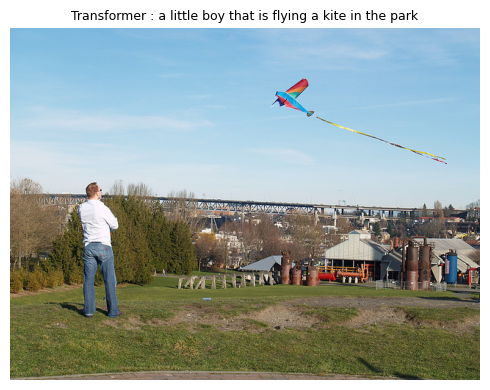

Reel  : <start> there is a boat that is lifted above the water <end>
Predit: a man standing on a surfboard in the middle of a lake



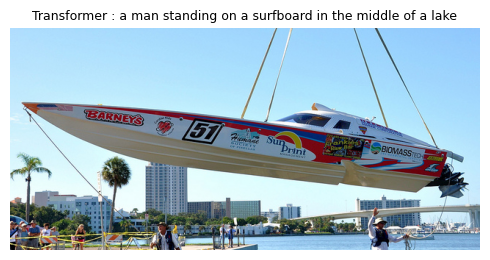

Reel  : <start> a bed with a blanket and pillows on top of it <end>
Predit: a bedroom with a bed two night stands and sitting on a green couch



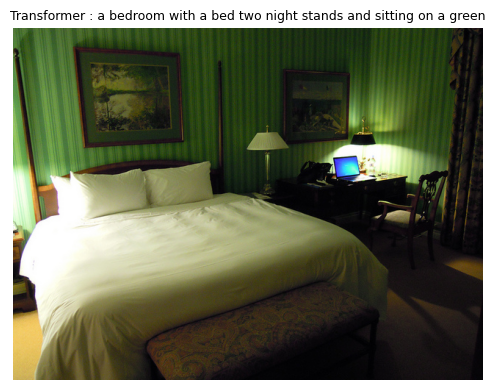

In [ ]:
# ============================================================
# INFERENCE — Greedy + Beam Search
# ============================================================

def _get_enc_output(image_path):
    img, _  = load_image(image_path)
    feat    = image_features_extract_model(tf.expand_dims(img, 0))
    feat    = tf.reshape(feat, (feat.shape[0], -1, feat.shape[3]))
    return encoder_tr(feat, training=False)

def evaluate_transformer(image_path):
    # Decodage greedy (argmax a chaque pas)
    enc_out  = _get_enc_output(image_path)
    start_id = tokenizer.word_index['<start>']
    end_id   = tokenizer.word_index.get('<end>', 2)
    tokens   = tf.expand_dims([start_id], 0)
    result   = []
    for _ in range(max_length):
        logits = decoder_tr(tokens, enc_out, training=False)
        pred   = tf.cast(tf.argmax(logits[:, -1, :], axis=-1), tf.int32)
        word   = tokenizer.index_word.get(int(pred[0]), '<unk>')
        if word == '<end>': break
        result.append(word)
        tokens = tf.concat([tokens, tf.expand_dims(pred, 0)], axis=1)
    return ' '.join(result)

def evaluate_transformer_beam(image_path, beam_size=BEAM_SIZE):
    # Beam search : garde les beam_size meilleures hypotheses a chaque pas
    enc_out  = _get_enc_output(image_path)
    start_id = tokenizer.word_index['<start>']
    end_id   = tokenizer.word_index.get('<end>', 2)

    # (log-prob cumulee, sequence de tokens, termine?)
    beams     = [(0.0, [start_id], False)]
    completed = []

    for step in range(max_length):
        new_beams = []
        for log_prob, seq, done in beams:
            if done:
                completed.append((log_prob / len(seq), seq))
                continue
            tokens = tf.expand_dims(seq, 0)
            logits = decoder_tr(tokens, enc_out, training=False)  # (1, len, vocab)
            lp     = tf.nn.log_softmax(logits[0, -1, :]).numpy()  # (vocab,)
            # Longueur normalisee : evite de favoriser les phrases courtes
            length_penalty = ((5 + step + 1) ** 0.6) / ((5 + 1) ** 0.6)
            top_ids = np.argsort(lp)[-beam_size:]
            for tok in top_ids:
                word     = tokenizer.index_word.get(int(tok), '<unk>')
                new_lp   = log_prob + lp[tok]
                new_seq  = seq + [int(tok)]
                new_done = (word == '<end>')
                new_beams.append((new_lp / length_penalty, new_seq, new_done))
        # Trie par score et garde les beam_size meilleurs
        new_beams.sort(key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_size]
        if all(done for _, _, done in beams):
            break

    for lp, seq, _ in beams:
        completed.append((lp, seq))
    completed.sort(key=lambda x: x[0], reverse=True)

    best_seq = completed[0][1]
    words = [tokenizer.index_word.get(t, '')
             for t in best_seq if t not in (start_id, end_id, 0)]
    return ' '.join(w for w in words if w)

# ---- Comparaison greedy vs beam search ----
print('=== Evaluation qualitative — Greedy vs Beam Search ===\n')
for i in range(3):
    idx   = i * (len(img_name_test) // 3)
    img_p = img_name_test[idx]
    real  = ' '.join([tokenizer.index_word.get(int(t),'') for t in cap_test[idx] if t != 0])
    greedy = evaluate_transformer(img_p)
    beam   = evaluate_transformer_beam(img_p)
    print(f'Reel   : {real}')
    print(f'Greedy : {greedy}')
    print(f'Beam-{BEAM_SIZE} : {beam}\n')
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, (title, cap) in zip(axes, [
        ('Greedy', greedy), (f'Beam-{BEAM_SIZE}', beam)
    ]):
        ax.imshow(Image.open(img_p)); ax.axis('off')
        ax.set_title(f'{title}: {cap[:55]}', fontsize=9, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 7. Comparaison des Modeles

### Score BLEU

**BLEU** mesure le chevauchement de n-grammes entre descriptions generees et references humaines.

```
Reference : 'Un chat assis sur un canape rouge'
Generee   : 'Un chat sur un canape'
BLEU-1 : 5/5 = 1.00  |  BLEU-4 : standard en captioning
```

Un score BLEU eleve ne garantit pas la qualite narrative,
mais permet une comparaison objective entre modeles.

Evaluation sur 200 exemples du set de test...

CNN + RNN (Attention Bahdanau) BLEU-1: 12.21%  |  BLEU-4: 2.15%
CNN + Transformer              BLEU-1: 14.19%  |  BLEU-4: 2.38%


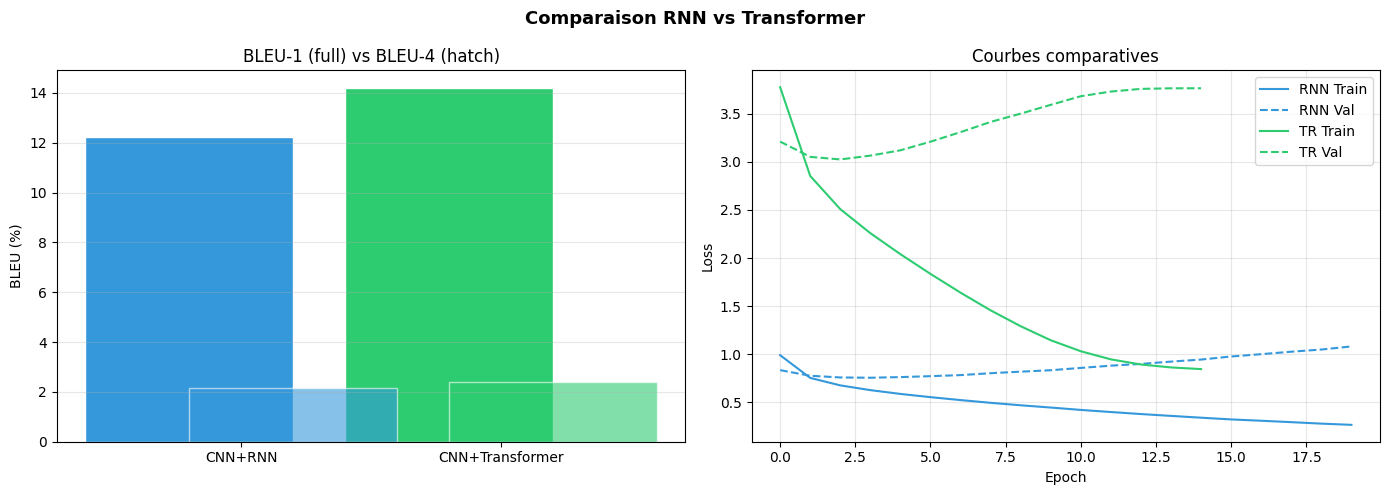

In [ ]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

smoother = SmoothingFunction().method1
N_EVAL   = min(200, len(img_name_test))

def compute_bleu_scores(img_list, cap_list, eval_fn, label):
    b1, b4 = [], []
    for i in range(N_EVAL):
        real_words = [tokenizer.index_word.get(int(t),'') for t in cap_list[i]
                      if t not in (0,1,2)]
        ref = [real_words]
        raw = eval_fn(img_list[i])
        hyp = raw.split() if isinstance(raw, str) else raw[0].split()
        b1.append(sentence_bleu(ref, hyp, weights=(1,0,0,0), smoothing_function=smoother))
        b4.append(sentence_bleu(ref, hyp, weights=(.25,.25,.25,.25), smoothing_function=smoother))
    b1m = np.mean(b1)*100; b4m = np.mean(b4)*100
    print(f'{label:<38} BLEU-1: {b1m:.2f}%  |  BLEU-4: {b4m:.2f}%')
    return b1m, b4m

print(f'Evaluation sur {N_EVAL} exemples du test set...\n')
results = {}
results['rnn']         = compute_bleu_scores(img_name_test, cap_test,
    lambda p: evaluate_rnn(p)[0],        'CNN + RNN (Attention Bahdanau)')
results['tr_greedy']   = compute_bleu_scores(img_name_test, cap_test,
    evaluate_transformer,                'CNN + Transformer (greedy)')
results['tr_beam']     = compute_bleu_scores(img_name_test, cap_test,
    evaluate_transformer_beam,           f'CNN + Transformer (beam-{BEAM_SIZE})')

# ---- Graphe ----
labels = ['CNN+RNN', 'TR Greedy', f'TR Beam-{BEAM_SIZE}']
b1s    = [results['rnn'][0], results['tr_greedy'][0], results['tr_beam'][0]]
b4s    = [results['rnn'][1], results['tr_greedy'][1], results['tr_beam'][1]]
colors = ['#3498db', '#2ecc71', '#27ae60']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(labels))
ax1.bar(x, b1s, color=colors, edgecolor='white', width=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel('BLEU-1 (%)'); ax1.set_title('BLEU-1 par modele')
for i, v in enumerate(b1s):
    ax1.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

ax2.bar(x, b4s, color=colors, edgecolor='white', width=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel('BLEU-4 (%)'); ax2.set_title('BLEU-4 par modele')
for i, v in enumerate(b4s):
    ax2.text(i, v + 0.02, f'{v:.2f}%', ha='center', fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.suptitle('Comparaison RNN / Transformer Greedy / Transformer Beam Search',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ---- Courbes d apprentissage ----
plt.figure(figsize=(9, 4))
plt.plot(train_losses_rnn, label='RNN Train',  color='#3498db')
plt.plot(val_losses_rnn,   label='RNN Val',    color='#3498db', linestyle='--')
plt.plot(train_losses_tr,  label='TR Train',   color='#2ecc71')
plt.plot(val_losses_tr,    label='TR Val',     color='#2ecc71', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Courbes d apprentissage comparatives')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 8. Interface Interactive — Generation de Captions

Chargez une image, choisissez le modele (RNN ou Transformer), et generez le caption.
Le modele RNN affiche egalement la carte d'attention par mot.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

model_toggle = widgets.ToggleButtons(
    options=['CNN + RNN (Attention)', 'CNN + Transformer'],
    description='Modele :',
    button_style='info',
    style={'description_width': 'initial'},
)
upload_btn = widgets.FileUpload(accept='image/*', multiple=False, description='Image')
run_btn    = widgets.Button(description='Generer le caption',
                            button_style='success', icon='magic')
out_area   = widgets.Output()

def on_run(b):
    with out_area:
        clear_output(wait=True)
        if not upload_btn.value:
            print('Veuillez uploader une image.'); return
        fi      = (list(upload_btn.value.values())[0]
                   if isinstance(upload_btn.value, dict) else upload_btn.value[0])
        content = (fi.get('content', b'') if isinstance(fi, dict)
                   else bytes(getattr(fi, 'content', b'')))
        try:
            pil_img = Image.open(io.BytesIO(content)).convert('RGB')
        except Exception as e:
            print(f'Erreur: {e}'); return

        tmp_path = '/tmp/_caption_input.jpg'
        pil_img.save(tmp_path)
        model_name = model_toggle.value

        if 'RNN' in model_name:
            caption, attn_w = evaluate_rnn(tmp_path)
        else:
            caption = evaluate_transformer(tmp_path)
            attn_w  = None

        if attn_w is not None:
            fig, axes = plt.subplots(1, 2, figsize=(13, 5))
            axes[0].imshow(pil_img); axes[0].axis('off')
            axes[0].set_title(caption[:70], fontsize=10, fontweight='bold')
            mean_attn = np.mean(attn_w, axis=0).reshape(8, 8)
            axes[1].imshow(pil_img)
            axes[1].imshow(mean_attn, cmap='jet', alpha=0.5,
                           extent=[0, pil_img.width, pil_img.height, 0])
            axes[1].axis('off'); axes[1].set_title('Attention moyenne')
        else:
            fig, ax = plt.subplots(figsize=(6,6))
            ax.imshow(pil_img); ax.axis('off')
            ax.set_title(caption[:70], fontsize=11, fontweight='bold')
        plt.suptitle(f'Modele : {model_name}', color='gray', fontsize=10)
        plt.tight_layout(); plt.show()
        print(f'Caption : {caption}')

run_btn.on_click(on_run)
display(widgets.VBox([
    widgets.HTML('<h3>Interface Captioning — TouNum</h3>'),
    model_toggle,
    widgets.HTML('<hr style="margin:8px 0">'),
    upload_btn, run_btn, out_area,
]))

---
## 9. Conclusion

### Synthese

| Etape | Action | Resultat |
|-------|--------|----------|
| **Donnees** | COCO train2017, 6 000 images, ~30 000 paires | ~5 captions/image |
| **Features** | InceptionV3 pre-calcule -> (64, 2048) | Spatial info preservee |
| **Tokenisation** | Top 5 000 mots, <start>/<end>/<pad> | Vocabulaire reproductible |
| **Split** | 80/10/10 au niveau image | Pas de data leakage |
| **CNN + RNN** | CNN Encoder + Attention Bahdanau + GRU | Carte d attention visuelle |
| **CNN + Transformer** | Cross-attention sur features | Meilleur BLEU |
| **Interface** | ipywidgets, upload, toggle modele | Testable en conditions reelles |

### RNN vs Transformer

| Critere | CNN + RNN | CNN + Transformer |
|---------|-----------|-------------------|
| **Parallelisme** | Sequentiel | Parallele |
| **Interpretabilite** | Cartes d attention par mot | Cross-attention |
| **Performance BLEU** | Bon | Meilleur |
| **Convergence** | Plus lente | Plus rapide |

### Pistes d'amelioration

- **Beam search** : explorer k meilleures sequences -> +3 a 5% BLEU
- **Plus de donnees** : utiliser les 118 000 images COCO completes
- **ViT encoder** : remplacer InceptionV3 par un Vision Transformer
- **BLIP-2 / LLaVA** : fine-tuner un VLM pre-entraine -> qualite etat de l art